In [1]:

import glob
import pandas as pd
import os
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import re
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from scipy.stats import spearmanr, pearsonr
from export_floats import store_to_tex

In [2]:
from plotting_util import rename_random,extract_seed,rename_linear_coder,rename_estimator,rename_model,extract_k, get_sort_type, facility_location_hotfix, vectorized_replace_k


In [3]:
linear_coder = "MSECoderProjUSimp"

In [4]:
def format_corr_with_stars(corr, p):
    if pd.isna(corr) or pd.isna(p):
        return ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''
    return f"{corr:.2f}{stars}"

def get_background_color_from_corr(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'background-color: white'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'background-color: white'
    abs_corr = max(0.0, min(1.0, abs(corr)))
    DARK_R, DARK_G, DARK_B = 50, 150, 200
    WHITE = 255
    r = int(WHITE - abs_corr * (WHITE - DARK_R))
    g = int(WHITE - abs_corr * (WHITE - DARK_G))
    b = int(WHITE - abs_corr * (WHITE - DARK_B))
    return f'background-color: rgb({r}, {g}, {b})'

def get_text_color_for_contrast(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'color: black'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'color: black'
    return 'color: white' if abs(corr) >= 0.6 else 'color: black'

def get_background_color_from_corr(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'background-color: white'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'background-color: white'
    abs_corr = max(0.0, min(1.0, abs(corr)))
    DARK_R, DARK_G, DARK_B = 50, 150, 200
    WHITE = 255
    r = int(WHITE - abs_corr * (WHITE - DARK_R))
    g = int(WHITE - abs_corr * (WHITE - DARK_G))
    b = int(WHITE - abs_corr * (WHITE - DARK_B))
    return f'background-color: rgb({r}, {g}, {b})'

def get_text_color_for_contrast(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'color: black'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'color: black'
    return 'color: white' if abs(corr) >= 0.6 else 'color: black'

In [5]:


df_validation = pq.ParquetDataset("results/validation").read().to_pandas()
df_validation["model"]  = df_validation["model"].apply(rename_model)
df_validation["estimator"]  = df_validation["estimator"].apply(rename_estimator)


In [6]:




df_validation["k"] = df_validation["explanation_type"].apply(extract_k)
df_validation["explanation_type_no_k"] = vectorized_replace_k(df_validation["explanation_type"], df_validation["k"])
df_validation["explanation_type"] = df_validation["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections



df_validation["sort_type"] = df_validation["explanation_type"].apply(get_sort_type)

df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("random examples with seed")]



In [7]:
df_scoring = pq.ParquetDataset("results/scoring").read().to_pandas()

df_scoring["NMSE"] =1.0 / (df_scoring["pred_gain"] + 1e-10)
df_scoring["k"] = df_scoring["explanation_type"].apply(extract_k)
df_scoring["explanation_type_no_k"] = df_scoring.apply(
    lambda row: row["explanation_type"].replace(str(row["k"]), "X"),
    axis=1
)
df_scoring["explanation_type"] = df_scoring["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections
df_scoring["model"] = df_scoring["model"].apply(rename_model)
df_scoring["estimator"] = df_scoring["estimator"].apply(rename_estimator)
df_scoring["fl"] = df_scoring["explanation_type"].apply(lambda x: "FL" if "facility" in x else "N")
import re

def get_lambda(x):
    match = re.search(r'lambda=([\d.]+)', x)
    return float(match.group(1)) if match else "-"

df_scoring["lambda"] = df_scoring["explanation_type"].apply(get_lambda)
import re

def remove_lambda(expr: str):
    # remove substrings like lambda=0.5 or lambda = 0.1
    return re.sub(r'lambda\s*=\s*[\d.]+', 'lambda=X', expr)

df_scoring["explanation_type_no_lambda"] = (
    df_scoring["explanation_type"].apply(remove_lambda)
)


In [8]:
# pair selection and random validation scores
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score_log_p"] = r["delta_log_p_selection"] - r["delta_log_p_random"]
r["validation_score_jsd"] = r["jsd_selection"] / r["jsd_random"]
r["validation_score_kld"] = r["kld(before||after)_selection"] - r["kld(before||after)_random"]



In [9]:
# merge with our score
rr = pd.merge(
    r,
    df_scoring,
    left_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type_selection", 
        "k",
        "document_idx"
    ],
    right_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type", 
        "k",
        "document_idx"
    ],
    suffixes=("_validation", "_scoring"),
    how="left"
)


 
                

## Validity

In [10]:
df = rr.reset_index()
df = df[(df["linear_coder"]=="MSECoderProjUSimp")]
df = df[df["explanation_type_selection"].str.contains("sanity")]


In [11]:

def remove_nans(a, b):
    mask = a.notna() & b.notna()
    a, b = a[mask], b[mask]
    return a, b


print(ttest_rel(*remove_nans(df["delta_log_p_selection"], df["delta_log_p_random"]),
                alternative="greater"))
print(ttest_rel(*remove_nans(df["jsd_selection"], df["jsd_random"]),
                alternative="greater"))


print(wilcoxon(*remove_nans(df["delta_log_p_selection"], df["delta_log_p_random"]),
               alternative="greater"))
print(wilcoxon(*remove_nans(df["jsd_selection"], df["jsd_random"]),
               alternative="greater"))


TtestResult(statistic=277.70145475945435, pvalue=0.0, df=44594)
TtestResult(statistic=29.772684666668056, pvalue=3.44218828022756e-193, df=44594)
WilcoxonResult(statistic=992371322.0, pvalue=0.0)
WilcoxonResult(statistic=983169492.5, pvalue=0.0)


In [12]:
a,b = remove_nans(df["delta_log_p_selection"], df["delta_log_p_random"])
store_to_tex("validationSanityCheckFractionLargerLogP", f"{np.mean(a > b)*100:.2f}\%")

In [13]:
a,b = remove_nans(df["jsd_selection"], df["jsd_random"])
store_to_tex("validationSanityCheckFractionLargerJSD", f"{np.mean(a > b)*100:.2f}\%")

## Correlation Analysis

In [14]:
def compute_and_export_correlations(rr, subset_filter=None, group_cols=None, sort_cols=None,
                                    row_label_cols=None, filename="./tables/validation.tex",):
    """
    Compute correlations of pred_gain vs validation scores and export to LaTeX.
    
    subset_filter: function to filter rr and rr_summary (takes DataFrame, returns filtered DataFrame)
    group_cols: list of columns to group by
    sort_cols: list of columns to sort by in the final table
    row_label_cols: list of columns to use as row labels (index) in the table
    """

    rr_subset = rr.copy()
       
                     

    if subset_filter:
        rr_subset = subset_filter(rr_subset)



    rows = []
    
    for keys, df in rr_subset.groupby(group_cols):
        if len(df) < 2:
            rows.append({**dict(zip(group_cols, keys)),
                         "spearman_pred_gain_log_p": "",
                         "spearman_pred_gain_jsd": "",
          })
            continue
            
        from scipy.stats import rankdata
        mask = df["pred_gain"].notna() & df["validation_score_log_p"].notna()
        x_rank = rankdata(df.loc[mask, "pred_gain"])
    
        y_rank = rankdata(df.loc[mask, "validation_score_log_p"])
        s_logp_rho = np.corrcoef(x_rank, y_rank)[0, 1]
    
        y_rank = rankdata(df.loc[mask, "validation_score_jsd"])
        s_jsd_rho  = np.corrcoef(x_rank, y_rank)[0, 1]


        rows.append({**dict(zip(group_cols, keys)),
                     "spearman_pred_gain_log_p": s_logp_rho,
                    "spearman_pred_gain_jsd": s_jsd_rho,
                    "n": mask.sum()
             })

    pooled_df = pd.DataFrame(rows)

    if row_label_cols:
        pooled_df.set_index(row_label_cols, inplace=True)
    else:
        pooled_df.set_index(group_cols, inplace=True)

    correlation_cols = ["spearman_pred_gain_log_p", "spearman_pred_gain_jsd"]
    hidden_cols = [col for col in pooled_df.columns if col not in correlation_cols]

    colnames = {
        "spearman_pred_gain_log_p": "$\\rho(\\xi^{{\\mathcal{{SR}}}}, \\xi^+)$",
        "spearman_pred_gain_jsd": "$\\rho(\\xi^{{\\mathcal{{SR}}}}, \\xi^{JSD})$",
    }

    styled = (
        pooled_df.sort_values(by=sort_cols or correlation_cols, ascending=True, na_position="last")
                 .style
                 .map(get_background_color_from_corr, subset=correlation_cols)
                 .map(get_text_color_for_contrast, subset=correlation_cols)
                 .format_index(colnames.get, axis=1)
                 .hide(axis="columns", subset=hidden_cols)
    )

    
    display(styled)

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    latex_tabular = styled.to_latex(convert_css=True, hrules=True,
                                   column_format='l' + 'l' * len(styled.data.columns))
    
    with open(filename, "w") as f:
        f.write(latex_tabular.replace("model", "Model").replace("estimator", "Estimator"))
    return styled





/tmp/ipykernel_732849/1451578135.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()


/tmp/ipykernel_732849/1451578135.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()


/tmp/ipykernel_732849/1451578135.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()


/tmp/ipykernel_732849/1451578135.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()


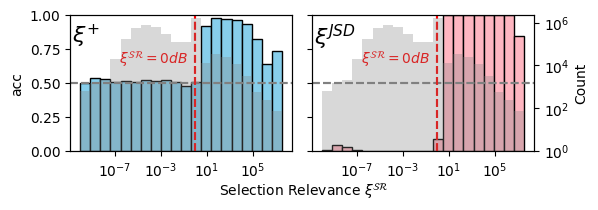

In [15]:
primary_colors = ["skyblue", "lightpink"]
def acc_bins_plot_dual(rr, x_cols, subset_filter=None, bins=20,
                       filename="./figures/acc_bins_plot_dual_sideby.pdf",
                       ):
    if len(x_cols) != 2:
        raise ValueError("x_cols must be a list of exactly 2 column names")

    # 1 row, 2 columns, wider figure
    fig, axes = plt.subplots(1, 2, figsize=(6, 2), sharey=True)
    fig.subplots_adjust(wspace=0.3, top=0.85)  # leave space for legend

    all_handles, all_labels = [], []

    for i, (ax, x_col) in enumerate(zip(axes, x_cols)):
        rr_subset = rr.copy()
        if subset_filter:
            rr_subset = subset_filter(rr_subset)

        rr_subset = rr_subset.dropna(subset=["pred_gain", x_col])
        y_score = rr_subset["pred_gain"]

        # Log-spaced bins
        bin_edges = np.logspace(
            np.log10(max(y_score.min(), 1e-10)),
            np.log10(y_score.max()),
            bins + 1
        )
        rr_subset["bin"] = pd.cut(y_score, bins=bin_edges, include_lowest=True)

        def stat(df):
            y_true = (df[x_col] > 0)
            y_pred = (df["pred_gain"] > 1)
            return pd.Series({
                "mean_pred": df["pred_gain"].mean(),
                "acc": accuracy_score(y_pred, y_true),
                "count": len(df)
            })

        binned = rr_subset.groupby("bin").apply(stat).reset_index()

        bin_left = bin_edges[:-1]
        bin_right = bin_edges[1:]
        bin_widths = bin_right - bin_left

        # Primary axis: accuracy
        h_acc = ax.bar(
            bin_left,
            binned["acc"],
            width=bin_widths,
            align="edge",
            edgecolor="black",
            color=primary_colors[i],
            label="acc"
        )
        if i == 0:
            ax.set_ylabel("acc")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="gray", ls="--")
        ax.axvline(1, color="r", ls="--")
        ax.set_xscale("log")
        ax.axhline(0.5, color="gray", ls="--")
        ax.axvline(1, color="r", ls="--")
        ax.text(0.00025, 0.75, r"$\xi^{\mathcal{SR}}=0dB$", ha="center", va="top",color="red")

        # Add x_col name in top-left corner of the axis
        ax.text(
            0.01, 0.95, '$\\xi^{+}$' if 'log' in x_col else '$\\xi^{JSD}$', transform=ax.transAxes,
            ha="left", va="top", fontsize=16, fontweight="bold"
        )

        # ax.set_xlabel(r"Prediction gain $\xi^{PG}$")
     #   ax.set_title(x_col)
        # Secondary axis: count
        ax2 = ax.twinx()
        h_count = ax2.bar(
            bin_left,
            binned["count"],
            width=bin_widths,
            align="edge",
            color="gray",
            alpha=0.3,
            label="Count"
        )
        # Only show secondary axis ticks and label on the right subplot
        if i == 1:
            ax2.set_ylabel("Count")
            ax2.tick_params(axis='y', which='both', labelcolor='black')
        else:
            ax2.set_yticks([])  # hide ticks
            ax2.set_ylabel("")  # hide label
            ax2.yaxis.set_visible(False)

        ax2.set_yscale("log")
        ax2.set_ylim(1, max(binned["count"].max(), 1) * 1.5)

        # Collect handles/labels for combined legend
        all_handles += [h_acc, h_count]
        # all_handles = all_handles[0:1] + all_handles[2:3]
        all_labels += ["acc", "Count"]


    # Combined legend at top center
    # fig.legend(all_handles, all_labels, loc='lower right', ncol=2, bbox_to_anchor=(0.95, -0.075))
    fig.text(0.5, 0.02, r"Selection Relevance $\xi^{\mathcal{SR}}$", ha='center', va='center',)

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

acc_bins_plot_dual(
rr,
x_cols=[ "validation_score_log_p","validation_score_jsd",],
subset_filter=lambda df: df[df["linear_coder"]==linear_coder],
bins=20,
filename=f"./figures/reliability_{linear_coder}_dual.pdf",
)


In [16]:

def categorize(expl_type):
    if "facility" in expl_type:


        regex = r"lambda=(.*)"

        matches = re.finditer(regex, expl_type, re.MULTILINE)
       
        return next(matches).groups()[0]
    elif any(x in expl_type for x in ["DIVINE", "AIDE", "Self"]):
        return "Other"
    else:
        return "Naive"
categorize("10 by facility location from Top-100 least influential (scores closest to zero). lambda=1.0")

'1.0'

## Overall

In [17]:
# full
d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)],
    group_cols=["train_dataset","train_split","test_dataset","test_split",],
    sort_cols=[],
    row_label_cols=[],
    filename=f"./tables/validation/full/{linear_coder}.tex",
)
store_to_tex("validationOverallCorrelationLogP", f"{d.data['spearman_pred_gain_log_p'].values[0]:.2f}")
store_to_tex("validationOverallCorrelationJSD", f"{d.data['spearman_pred_gain_jsd'].values[0]:.2f}")

,,,,"$\rho(\xi^{{\mathcal{{SR}}}}, \xi^+)$","$\rho(\xi^{{\mathcal{{SR}}}}, \xi^{JSD})$"
train_dataset,train_split,test_dataset,test_split,,
loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,0.093349,0.072748


## Where gain is large

In [18]:
# only where pred_gain > 0dB

d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder) & (df["pred_gain"] > 1)],
    group_cols=["train_dataset","train_split","test_dataset","test_split",],
    sort_cols=[],
    row_label_cols=[],
    filename=f"./tables/validation/full/pred_gain_filt{linear_coder}.tex",
)
store_to_tex("validationLargeGainCorrelationLogP", f"{d.data['spearman_pred_gain_log_p'].values[0]:.2f}")
store_to_tex("validationLargeGainCorrelationJSD", f"{d.data['spearman_pred_gain_jsd'].values[0]:.2f}")

,,,,"$\rho(\xi^{{\mathcal{{SR}}}}, \xi^+)$","$\rho(\xi^{{\mathcal{{SR}}}}, \xi^{JSD})$"
train_dataset,train_split,test_dataset,test_split,,
loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,0.575404,0.374393


In [19]:
# only where pred_gain > 0dB
# per estimator
d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder) & (df["pred_gain"] > 1)],
    group_cols=["estimator", "train_dataset","train_split","test_dataset","test_split",],
    sort_cols=["estimator"],
    row_label_cols=["estimator"],
    filename=f"./tables/validation/per_estimator/pred_gain_filt{linear_coder}.tex",
)
for estimator, row in d.data.iterrows():
    print(f"{row['spearman_pred_gain_log_p']:.2f}")
    store_to_tex(f"validationLargeGainCorrelationLogP{estimator}", f"{row['spearman_pred_gain_log_p']:.2f}")
    store_to_tex(f"validationLargeGainCorrelationJSD{estimator}", f"{row['spearman_pred_gain_jsd']:.2f}")

,"$\rho(\xi^{{\mathcal{{SR}}}}, \xi^+)$","$\rho(\xi^{{\mathcal{{SR}}}}, \xi^{JSD})$"
estimator,,
BM25Estimator,0.504711,0.317209
DataInfEstimator,-0.068170,0.460028
LESSEstimator,-0.088571,0.463996


0.50
-0.07
-0.09


## Per-model and estimator

In [20]:
# full
d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)],
    group_cols=["model","estimator","train_dataset","train_split","test_dataset","test_split",],
    sort_cols=["estimator","model",],
    row_label_cols=["estimator","model",],
    filename=f"./tables/validation/per_model_estimator/{linear_coder}.tex",
)


In [21]:
# only where pred_gain > 0dB

d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder) & (df["pred_gain"] > 1)],
    group_cols=["model","estimator","train_dataset","train_split","test_dataset","test_split",],
    sort_cols=["estimator","model",],
    row_label_cols=["estimator","model",],
    filename=f"./tables/validation/per_model_estimator/pred_gain_filt{linear_coder}.tex",

)


## Effect of FL

In [22]:

rr_cat = rr.copy()

rr_cat["cat"] = rr_cat["explanation_type_selection"].apply(categorize)
rr_cat = rr_cat[(rr_cat["cat"] != "Other") & (rr_cat["cat"] != "Naive")]
rr_cat = rr_cat[rr_cat["linear_coder"]==linear_coder]

In [23]:
d = compute_and_export_correlations(
    rr_cat,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)  & (df["pred_gain"] > 1)],
    group_cols=["estimator","train_dataset","train_split","test_dataset","test_split", "cat"],
    sort_cols=["estimator","cat"],
    row_label_cols=["estimator", "cat",],
    filename=f"./tables/validation/per_strategy/{linear_coder}.tex"
)
import pandas as pd
import numpy as np
from scipy.stats import norm


def fisher_z_comparison(d, *, tail, signif_col, tex_key):
    """
    tail: 'upper'  -> tests z > 0   (FL decreases rho, more negative)
          'lower'  -> tests z < 0   (FL increases rho, less negative)
    """
    result = []
    df_naive = d.data.xs("0.0", level="cat")

    for cat in set(d.data.index.get_level_values("cat")):
        df_fl = d.data.xs(cat, level="cat")

        # Fisher z-transform
        z_naive = np.arctanh(df_naive[["spearman_pred_gain_log_p"]])
        z_fl = np.arctanh(df_fl[["spearman_pred_gain_log_p"]])

        diff = z_naive - z_fl
        se = np.sqrt(1 / (df_naive["n"] - 3) + 1 / (df_fl["n"] - 3))

        z_stat = diff["spearman_pred_gain_log_p"] / se

        if tail == "upper":
            pvals = 1 - norm.cdf(z_stat)
        elif tail == "lower":
            pvals = norm.cdf(z_stat)
        else:
            raise ValueError("tail must be 'upper' or 'lower'")

        df_out = diff.assign(
            cat=cat,
            z_stat=z_stat,
            pvalue=pvals
        )

        result.append(df_out)

    final_df = pd.concat(result).set_index("cat", append=True)
    final_df[signif_col] = final_df["pvalue"] < 0.05

    df_sig = final_df[final_df[signif_col]].index.to_frame(index=False)

    grouped = df_sig.groupby("estimator")["cat"].apply(
        lambda x: ",".join(sorted(x, key=float))
    )

    formatted = ", ".join(
        f"{est.split('Estimator')[0]} $\\lambda=\\{{ {vals} \\}}$"
        for est, vals in grouped.items()
    )

    store_to_tex(tex_key, formatted)




fisher_z_comparison(
    d,
    tail="upper",
    signif_col="correlation_more_negative",
    tex_key="validationLargeGainSettingsWhereFLDecreasesRho",
)

fisher_z_comparison(
    d,
    tail="lower",
    signif_col="correlation_less_negative",
    tex_key="validationLargeGainSettingsWhereFLIncreasesRho",
)


### 2D histograms

count    2.973000e+06
mean     1.632871e-02
std      6.711586e-01
min     -9.548828e+00
25%     -2.563171e-01
50%      1.159668e-03
75%      2.682270e-01
max      2.077441e+01
Name: validation_score_log_p, dtype: float64

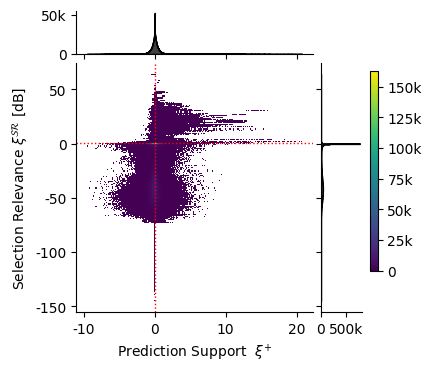

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as mticker

def plot_pred_gain_vs_validation(rr_cat, x_col, output_file=None, bins=200, cmap="viridis",
                                 single_facet=False, percentile_range=None, df_filter=lambda df: df):
    """
    Create a JointGrid-like 2D histogram of pred_gain vs a validation score with marginal histograms.

    Parameters:
        rr_cat (pd.DataFrame): DataFrame containing 'pred_gain', 'estimator', and x_col
        x_col (str): Column name for x-axis ('validation_score_log_p' or 'validation_score_JSD')
        output_file (str, optional): Path to save PDF. If None, figure is not saved.
        bins (int): Number of bins for 2D histogram
        cmap (str): Colormap to use
        single_facet (bool): If True, plot all data in a single JointGrid
        percentile_range (list or tuple, optional): [lower, upper] percentiles (0–1) to filter pred_gain
    """
    rr_clean = rr_cat.dropna(subset=[x_col, "pred_gain"]).copy()
    rr_clean["pred_gain"] = 10 * np.log10(rr_clean["pred_gain"])
    display(rr_clean[x_col].describe())
    
    rr_clean = df_filter(rr_clean)
    if percentile_range is not None:
        lower, upper = percentile_range
        lower_thresh = np.percentile(rr_clean["pred_gain"], lower * 100)
        upper_thresh = np.percentile(rr_clean["pred_gain"], upper * 100)
        rr_clean = rr_clean[(rr_clean["pred_gain"] >= lower_thresh) & (rr_clean["pred_gain"] <= upper_thresh)]

    # --- Formatter for all ticks in 'k' ---
    k_formatter = mticker.FuncFormatter(lambda x, pos: f'{int(x/1e3)}k' if x >= 1e3 else f'{int(x)}')

    if single_facet:
        g = sns.JointGrid(data=rr_clean, x=x_col, y="pred_gain", marginal_ticks=True, height=4)
        
        # Color normalization
        all_counts = np.histogram2d(rr_clean[x_col], rr_clean["pred_gain"], bins=bins)[0]
        norm = mpl.colors.LogNorm(vmin=1, vmax=all_counts.max())
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # Inset colorbar
        cax = g.fig.add_axes([0.9, 0.25, 0.02, 0.5])
        cax.set_ylabel("count (log)")

        # 2D histogram
        g.plot_joint(
            sns.histplot,
            bins=bins,
            pmax=1,
            cbar=True,
            cbar_ax=cax,
            cmap=cmap,
            discrete=(False, False),
            log_scale=(False, False)
        )

        # Marginals
        g.plot_marginals(sns.histplot, element="step", color="black")

        # Reference lines
        g.ax_joint.axvline(x=0, color='red', linestyle=':', linewidth=1)
        g.ax_joint.axhline(y=1, color='red', linestyle=':', linewidth=1)

        if "jsd" in x_col:
            xmin, xmax = 0, 3
            g.ax_joint.set_xlim(xmin, xmax)
            g.ax_marg_x.set_xlim(xmin, xmax)

        # Set axis labels
        g.set_axis_labels("Prediction Support  $\\xi^{+}$",
                          "Selection Relevance $\\xi^{{\\mathcal{{SR}}}}$ [dB]")
        g.fig.subplots_adjust(top=0.9, right=0.88)

        # --- Apply 'k' formatting ---
        g.ax_joint.xaxis.set_major_formatter(k_formatter)
        g.ax_joint.yaxis.set_major_formatter(k_formatter)

        g.ax_marg_x.xaxis.set_major_formatter(k_formatter)
        g.ax_marg_x.yaxis.set_major_formatter(k_formatter)
        g.ax_marg_y.xaxis.set_major_formatter(k_formatter)
        g.ax_marg_y.yaxis.set_major_formatter(k_formatter)

        cax.yaxis.set_major_formatter(k_formatter)

        if output_file:
            g.fig.savefig(output_file, format="pdf", bbox_inches="tight")
        plt.show()

    else:
        g = sns.FacetGrid(rr_clean, col="estimator", col_wrap=4, height=3, sharex=True, sharey=True)
        g.map_dataframe(
            sns.histplot,
            x=x_col,
            y="pred_gain",
            bins=bins,
            pmax=1,
            cbar=False,
            log_scale=(False, False),
            cmap=cmap,
        )

        # Reference lines
        for ax in g.axes.flatten():
            ax.axvline(x=0, color='red', linestyle=':', linewidth=1)

        all_counts = np.histogram2d(rr_clean[x_col], rr_clean["pred_gain"], bins=bins)[0]
        norm = mpl.colors.LogNorm(vmin=1, vmax=all_counts.max())
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # Add colorbar
        cbar_ax = g.fig.add_axes([0.7, 0.15, 0.01, 0.7])
        cbar = g.fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label("count (log)")

        # --- Apply 'k' formatting ---
        for ax in g.axes.flatten():
            ax.xaxis.set_major_formatter(k_formatter)
            ax.yaxis.set_major_formatter(k_formatter)
        cbar.ax.yaxis.set_major_formatter(k_formatter)

        g.fig.subplots_adjust(right=0.9, top=0.9, bottom=0.1, hspace=0.1, wspace=0.1)
        if output_file:
            g.fig.savefig(output_file, format="pdf", bbox_inches="tight")
        plt.show()


plot_pred_gain_vs_validation(rr_cat, "validation_score_log_p", single_facet=True, output_file="figures/pred_gain_validation_logp_single.pdf", percentile_range=[0.0, 1])

count    2.973000e+06
mean     1.632871e-02
std      6.711586e-01
min     -9.548828e+00
25%     -2.563171e-01
50%      1.159668e-03
75%      2.682270e-01
max      2.077441e+01
Name: validation_score_log_p, dtype: float64

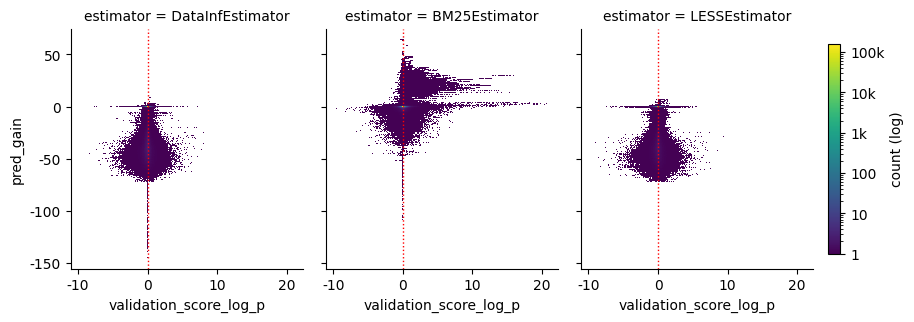

In [25]:
plot_pred_gain_vs_validation(rr_cat, "validation_score_log_p", output_file="figures/pred_gain_validation_logp.pdf")

count    2.973000e+06
mean     1.285213e+00
std      2.561028e+01
min     -1.167536e+04
25%      9.387924e-01
50%      1.016756e+00
75%      1.126815e+00
max      8.486192e+03
Name: validation_score_jsd, dtype: float64

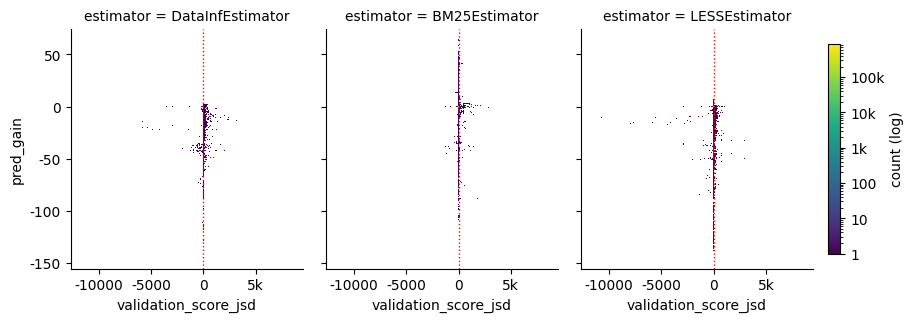

In [26]:
plot_pred_gain_vs_validation(rr_cat, "validation_score_jsd", output_file="figures/pred_gain_validation_JSD.pdf")
